In [21]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report,confusion_matrix,ConfusionMatrixDisplay



In [22]:
train = pd.read_csv(r'Dataset\train.csv')

In [23]:
TARGET = "health_condition"
FEATURES = [c for c in train.columns if c not in ["id", TARGET]]

In [24]:
numeric_cols = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure",
                "step_count", "exercise_duration", "water_intake"]
categorical_cols = ["diet_type", "stress_level", "sleep_quality",
                     "physical_activity_level", "smoking_alcohol", "gender"]

In [25]:
for col in numeric_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)



for col in categorical_cols:
    train[col] = train[col].fillna("missing")


In [26]:
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    encoders[col] = le
 
target_encoder = LabelEncoder()
train["target_enc"] = target_encoder.fit_transform(train[TARGET])
print("Class mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))

Class mapping: {'at-risk': np.int64(0), 'fit': np.int64(1), 'unhealthy': np.int64(2)}


In [27]:
X = train[FEATURES]
y = train["target_enc"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_val.shape)

(552070, 13) (138018, 13)


In [1]:
rf_model = RandomForestClassifier(
    n_estimators=300,      
    max_depth=12,           
    min_samples_leaf=20,    
    n_jobs=-1,              
    random_state=42
)

rf_model.fit(X_train, y_train)


NameError: name 'RandomForestClassifier' is not defined

In [ ]:
val_pred = rf_model.predict(X_val)

In [ ]:
print("Accuracy:", accuracy_score(y_val, val_pred))
print("f1_score:", f1_score(y_val, val_pred,average="macro"))  
print(classification_report(y_val, val_pred, target_names=target_encoder.classes_))
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances)

Accuracy: 0.9657218623657784
f1_score: 0.9034300035274122
              precision    recall  f1-score   support

     at-risk       0.96      1.00      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.99      0.76      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.97      0.85      0.90    138018
weighted avg       0.97      0.97      0.96    138018

stress_level               0.440493
sleep_duration             0.374830
physical_activity_level    0.093888
bmi                        0.037166
step_count                 0.014615
exercise_duration          0.012627
sleep_quality              0.012419
smoking_alcohol            0.006914
calorie_expenditure        0.002667
heart_rate                 0.001798
water_intake               0.001773
diet_type                  0.000406
gender                     0.000404
dtype: float64


[[118137    295     80]
 [  1551   6380     30]
 [  2761     14   8770]]


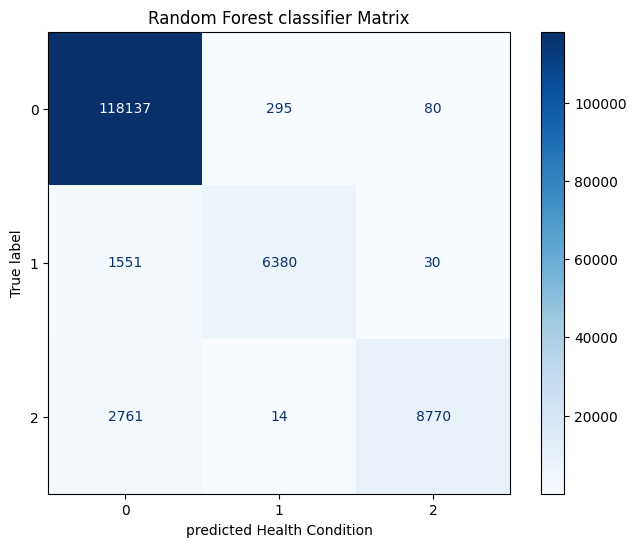

In [ ]:


cm = confusion_matrix(y_val, val_pred)
print(cm)


fig, ax = plt.subplots(figsize=(8,6))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    val_pred,
    display_labels=rf_model.classes_,
    cmap="Blues",
    ax=ax
)

plt.title("Random Forest classifier Matrix")
plt.xlabel("predicted Health Condition")
plt.show()

In [ ]:
os.makedirs("models_rf", exist_ok=True)

joblib.dump(rf_model, "models_rf/rf_model.pkl")
joblib.dump(encoders, "models_rf/feature_encoders.pkl")
joblib.dump(target_encoder, "models_rf/target_encoder.pkl")
joblib.dump(FEATURES, "models_rf/feature_names.pkl")

preprocessing_info = {
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "numeric_medians": {col: train[col].median() for col in numeric_cols},
    "categorical_fill": "missing"
}

joblib.dump(preprocessing_info, "models_rf/preprocessing_info.pkl")

print("All artifacts saved successfully!")

All artifacts saved successfully!


In [ ]:
test_df = pd.read_csv(r"Dataset\test.csv")

test_ids = test_df["id"]

# Fill numeric missing values
for col in preprocessing_info["numeric_columns"]:
    median = preprocessing_info["numeric_medians"][col]
    test_df[col] = test_df[col].fillna(median)

# Fill categorical missing values
for col in preprocessing_info["categorical_columns"]:
    test_df[col] = test_df[col].fillna(preprocessing_info["categorical_fill"])

# Encode categorical columns
for col in preprocessing_info["categorical_columns"]:
    encoder = encoders[col]
    known_values = set(encoder.classes_)

    test_df[col] = test_df[col].apply(
        lambda x: x if x in known_values else "missing"
    )

    test_df[col] = encoder.transform(test_df[col])

# Keep correct feature order
test_df = test_df[FEATURES]

# Predict
pred_enc = rf_model.predict(test_df)
predictions = target_encoder.inverse_transform(pred_enc)

# Create submission
submission = pd.DataFrame({
    "id": test_ids,
    "health_condition": predictions
})

# Save
os.makedirs("Submissions", exist_ok=True)
submission.to_csv("Submissions/rf_submission.csv", index=False)

print("RF submission created successfully!")
print(submission.head())
print(submission.shape)

RF submission created successfully!
       id health_condition
0  690088        unhealthy
1  690089          at-risk
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
(295753, 2)
